In [1]:
import json
import os
from PIL import Image
import torch
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
# Đường dẫn
json_path = "/mnt/VLAI_data/ViVQA-X/ViVQA-X_val.json"
coco_img_dir = "/mnt/VLAI_data/COCO_Images/val2014/"

# Đọc file JSON
with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

samples = []
for item in data:
    img_path = os.path.join(coco_img_dir, item["image_name"])
    # Mở ảnh thành PIL Image
    image = Image.open(img_path).convert("RGB")
    sample = {
        "question": item["question"],
        "image": image,  # <-- PIL Image object
        "image_path": img_path,
        "explanation": item["explanation"],  # list
        "answer": item["answer"],
        "question_id": item["question_id"]
    }
    samples.append(sample)

In [2]:
samples[4]

{'question': 'Người đàn ông đội mũ đang làm gì?',
 'image': <PIL.Image.Image image mode=RGB size=640x360>,
 'image_path': '/mnt/VLAI_data/COCO_Images/val2014/COCO_val2014_000000262531.jpg',
 'explanation': ['anh ấy đang cưỡi ván trượt',
  'anh ta cúi thấp trên một tấm ván có bánh xe',
  'anh ấy đang cưỡi ván trượt'],
 'answer': 'lướt ván',
 'question_id': '262531001'}

## Using Pos-tagging

In [ ]:
# Hàm trích xuất danh từ
def extract_nouns(text):
    normalized = text_normalize(text)
    tagged = pos_tag(normalized)
    nouns = [word for word, tag in tagged if tag in ['N', 'Np']]
    return nouns

# Xử lý tất cả samples
samples_with_nouns = []
for item in samples:
    img_path = os.path.join(coco_img_dir, item["image_name"])
    image = Image.open(img_path).convert("RGB")
    
    # Trích xuất danh từ từ câu hỏi
    question_nouns = extract_nouns(item["question"])
    
    # Trích xuất danh từ từ giải thích
    explanation_nouns = []
    for exp in item["explanation"]:
        explanation_nouns.extend(extract_nouns(exp))
    
    sample = {
        "question": item["question"],
        "question_nouns": question_nouns,
        "image": image,
        "image_path": img_path,
        "explanation": item["explanation"],
        "explanation_nouns": list(set(explanation_nouns)),  # unique nouns
        "answer": item["answer"],
        "question_id": item["question_id"]
    }
    samples_with_nouns.append(sample)

# Kiểm tra kết quả
print("Câu hỏi:", samples_with_nouns[0]["question"])
print("Danh từ trong câu hỏi:", samples_with_nouns[0]["question_nouns"])
print("\nGiải thích:", samples_with_nouns[0]["explanation"])
print("Danh từ trong giải thích:", samples_with_nouns[0]["explanation_nouns"])

Câu hỏi: Đây có phải là bức ảnh chụp nhiều độ phơi sáng của vận động viên trượt tuyết mặc áo đen không?
Danh từ trong câu hỏi: ['ảnh', 'độ', 'vận động viên', 'trượt tuyết', 'áo']

Giải thích: ['hình người mặc cùng một bộ quần áo khi trượt xuống dốc', 'có vẻ như là cùng một người trượt tuyết làm những pha nhào lộn khác nhau', 'cùng một người trượt tuyết xuất hiện nhiều lần']
Danh từ trong giải thích: ['bộ quần áo', 'dốc', 'khi', 'lần', 'người', 'pha nhào lộn', 'nhau', 'hình']


## KeyBert + VLMs

In [3]:
# ==================== INSTALLATION ====================
# pip install keybert transformers torch pillow supervision

import torch
from PIL import Image
from keybert import KeyBERT
from transformers import AutoProcessor, AutoModelForImageTextToText
import supervision as sv
from typing import List, Tuple, Optional


# ==================== CONFIG ====================
class Config:
    QWEN_MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"
    KEYBERT_MODEL = "all-MiniLM-L6-v2"
    VIETNAMESE_MODEL = "keepitreal/vietnamese-sbert"
    
    MAX_NEW_TOKENS = 1024
    TOP_N_KEYWORDS = 3
    MIN_KEYWORD_SCORE = 0.3
    
    COLOR_PALETTE = sv.ColorPalette.from_hex([
        "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
        "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
    ])


# ==================== KEYWORD EXTRACTOR ====================
class KeywordExtractor:
    def __init__(self, language: str = "english"):
        model = Config.VIETNAMESE_MODEL if language == "vietnamese" else Config.KEYBERT_MODEL
        self.kw_model = KeyBERT(model=model)
        print(f"✓ KeyBERT: {model}")
    
    def extract(self, query: str, top_n: int = Config.TOP_N_KEYWORDS, 
                min_score: float = Config.MIN_KEYWORD_SCORE) -> str:
        keywords = self.kw_model.extract_keywords(
            query,
            keyphrase_ngram_range=(1, 2),
            top_n=top_n * 2,
            use_mmr=True,
            diversity=0.5
        )
        
        filtered = [kw for kw, score in keywords if score >= min_score][:top_n]
        result = ", ".join(filtered)
        
        print(f"Query: '{query}'\nKeywords: {filtered}")
        return result


# ==================== QWEN DETECTOR ====================
class QwenDetector:
    def __init__(self, model_id: str = Config.QWEN_MODEL_ID):
        self.processor = AutoProcessor.from_pretrained(model_id)
        self.model = AutoModelForImageTextToText.from_pretrained(model_id).to("cuda")
        print(f"✓ Qwen3-VL: {model_id}")
    
    def detect(self, image: Image.Image, target: str) -> str:
        prompt = f"Outline the position of {target} and output all the coordinates in JSON format."
        
        messages = [{
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt}
            ]
        }]
        
        inputs = self.processor.apply_chat_template(
            messages, tokenize=True, add_generation_prompt=True,
            return_dict=True, return_tensors="pt"
        ).to("cuda")
        
        with torch.inference_mode():
            gen = self.model.generate(**inputs, max_new_tokens=Config.MAX_NEW_TOKENS, temperature=0.1, do_sample=False)
        
        trimmed = [g[len(i):] for i, g in zip(inputs.input_ids, gen)]
        result = self.processor.batch_decode(trimmed, skip_special_tokens=True)[0]
        
        print(f"Detection: {result}")
        return result


# ==================== VISUALIZER ====================
class Visualizer:
    @staticmethod
    def annotate(image: Image.Image, detections: sv.Detections) -> Image.Image:
        text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
        thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
        
        box_annotator = sv.BoxAnnotator(
            color=Config.COLOR_PALETTE, 
            thickness=thickness,
            color_lookup=sv.ColorLookup.INDEX  
        )
        label_annotator = sv.LabelAnnotator(
            color=Config.COLOR_PALETTE,
            text_color=sv.Color.BLACK,
            text_scale=text_scale,
            text_thickness=thickness - 1,
            color_lookup=sv.ColorLookup.INDEX 
        )
        
        annotated = image.copy()
        annotated = box_annotator.annotate(annotated, detections)
        annotated = label_annotator.annotate(annotated, detections)
        return annotated


# ==================== PIPELINE ====================
class KeyBERTQwenPipeline:
    def __init__(self, language: str = "english", qwen_model: str = Config.QWEN_MODEL_ID):
        print("\n" + "="*60)
        print("🚀 Initializing Pipeline")
        print("="*60)
        
        self.keyword_extractor = KeywordExtractor(language)
        self.detector = QwenDetector(qwen_model)
        self.visualizer = Visualizer()
        
        print("="*60)
        print("✅ Ready\n")
    
    def run(self, image_path: str, question: str, explanation_list: List[str], 
                top_n: int = Config.TOP_N_KEYWORDS,
                min_score: float = Config.MIN_KEYWORD_SCORE) -> Tuple[Image.Image, Optional[sv.Detections]]:
        
        print("\n" + "="*60)
        print("🔄 START")
        print("="*60)
        # Lowercase explanation để nó thành subordinate clause
        explanations = [e[0].lower() + e[1:] for e in explanation_list]
        query = f"{question} vì {', '.join(explanations)}"
        
        # Extract keywords
        print("\n[1/4] Extracting keywords...")
        keywords = self.keyword_extractor.extract(query, top_n, min_score)
        
        # Load image
        print("\n[2/4] Loading image...")
        image = Image.open(image_path).convert("RGB")
        print(f"Image: {image.size}")
        
        # Detect
        print("\n[3/4] Detecting...")
        response = self.detector.detect(image, keywords)
        
        # Visualize
        print("\n[4/4] Visualizing...")
        try:
            detections = sv.Detections.from_vlm(
                vlm=sv.VLM.QWEN_3_VL,
                result=response,
                resolution_wh=image.size
            )
            # Bước 1: Filter theo confidence threshold
            detections = detections[detections.confidence > 0.25]

            # Bước 2: Loại bỏ overlapping boxes
            detections = detections.with_nms(threshold=0.9, class_agnostic=True)
            print(f"✅ Found After postprocess {len(detections)} object(s)")
            annotated = self.visualizer.annotate(image, detections)
        except Exception as e:
            print(f"⚠️ Error: {e}")
            return image, None
        
        print("\n" + "="*60)
        print("✅ COMPLETE")
        print("="*60 + "\n")
        
        return annotated, detections


pipeline = KeyBERTQwenPipeline(language="vietnamese")

/opt/miniconda3/envs/project_vivqanle_grpo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



🚀 Initializing Pipeline
✓ KeyBERT: keepitreal/vietnamese-sbert
✓ Qwen3-VL: Qwen/Qwen3-VL-2B-Instruct
✅ Ready




🔄 START

[1/4] Extracting keywords...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Query: 'Người đàn ông đội mũ đang làm gì? vì anh ấy đang cưỡi ván trượt, anh ta cúi thấp trên một tấm ván có bánh xe, anh ấy đang cưỡi ván trượt'
Keywords: ['cưỡi ván', 'trượt anh']

[2/4] Loading image...
Image: (640, 360)

[3/4] Detecting...
Detection: ```json
[
	{"bbox_2d": [607, 332, 719, 675], "label": "cưỡi ván, trượt anh"}
]
```

[4/4] Visualizing...
✅ Found After postprocess 1 object(s)

✅ COMPLETE



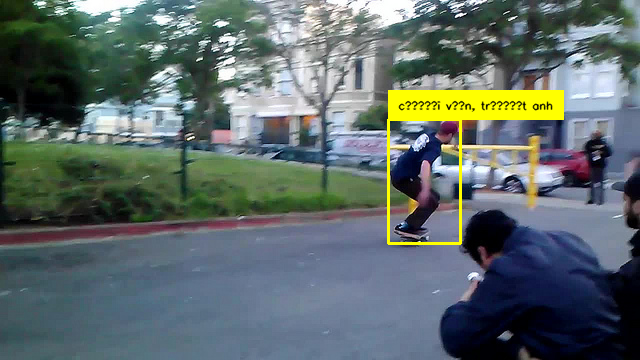

In [4]:
sample = samples[4]
annotated, detections = pipeline.run(
    sample['image_path'], 
    sample['question'],
    sample['explanation'] 
)

display(annotated)


🔄 START

[1/4] Extracting keywords...
Query: 'Những loại hoa trong bình? vì chúng có màu vàng và đỏ với cánh hoa hình bầu dục, chúng trông như được tạo ra từ hai môi, chúng là những bông hoa mùa xuân rực rỡ có hình chữ u'
Keywords: ['cánh hoa', 'rực rỡ']

[2/4] Loading image...
Image: (375, 500)

[3/4] Detecting...


Detection: ```json
[
	{"bbox_2d": [336, 12, 472, 135], "label": "cánh hoa, rực rỡ"},
	{"bbox_2d": [32, 125, 228, 265], "label": "cánh hoa, rực rỡ"},
	{"bbox_2d": [62, 105, 198, 252], "label": "cánh hoa, rực rỡ"},
	{"bbox_2d": [62, 65, 188, 145], "label": "cánh hoa, rực rỡ"},
	{"bbox_2d": [20, 145, 100, 235], "label": "cánh hoa, rực rỡ"},
	{"bbox_2d": [328, 135, 418, 275], "label": "cánh hoa, rực rỡ"},
	{"bbox_2d": [528, 115, 608, 165], "label": "cánh hoa, rực rỡ"},
	{"bbox_2d": [632, 79, 728, 175], "label": "cánh hoa, rực rỡ"},
	{"bbox_2d": [658, 155, 724, 235], "label": "cánh hoa, rực rỡ"},
	{"bbox_2d": [752, 220, 832, 292], "label": "cánh hoa, rực rỡ"},
	{"bbox_2d": [872, 125, 994, 245], "label": "cánh hoa, rực rỡ"},
	{"bbox_2d": [872, 205, 994, 325], "label": "cánh hoa, rực rỡ"}
]
```

[4/4] Visualizing...
✅ Found After postprocess 12 object(s)

✅ COMPLETE



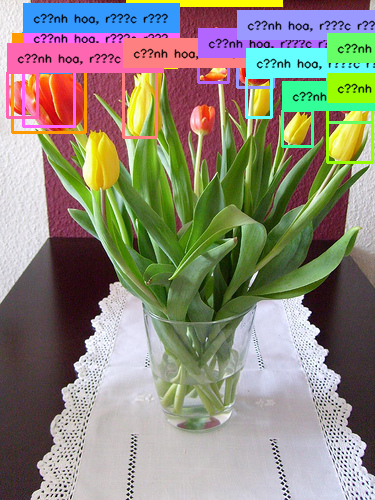

In [5]:
sample = samples[2]
annotated, detections = pipeline.run(
    sample['image_path'], 
    sample['question'],
    sample['explanation'] 
)

display(annotated)